All classes.

In [2]:
import torch
import pandas as pd

folder = f"cifar10_22500"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')
print("Keys: " + str(eval_qr_results.keys()))

# Find the closest quantile to the FPR threshold on nonmembers.
def get_tprs(eval_qr_results, train_qr_results, fpr):
    eval_preds = eval_qr_results['outputs'] < eval_qr_results['targets']
    fprs = torch.sum(eval_preds, dim=0) / eval_preds.shape[0]
    best_q_idx = torch.argmin(torch.abs(fprs - fpr))

    # Evaluate the per-class TPR and FPR on members using the best quantile found above.
    train_preds = train_qr_results['outputs'] < train_qr_results['targets']
    class_tprs = []
    for i in pd.unique(train_qr_results['labels'].numpy()):
        class_preds = train_preds[train_qr_results['labels'] == i]
        class_tpr = torch.sum(class_preds, dim=0) / class_preds.shape[0]
        class_tprs.append(class_tpr[best_q_idx].item())
    
    class_fprs = []
    for i in pd.unique(eval_qr_results['labels'].numpy()):
        class_preds = eval_preds[eval_qr_results['labels'] == i]
        class_fpr = torch.sum(class_preds, dim=0) / class_preds.shape[0]
        class_fprs.append(class_fpr[best_q_idx].item())

    avg_fpr = fprs[best_q_idx].item()
    avg_tpr = (torch.sum(train_preds, dim=0) / train_preds.shape[0])[best_q_idx].item()
    return avg_fpr, avg_tpr, class_tprs, class_fprs

fpr = 0.01
fpr, tpr, class_tprs, class_fprs = get_tprs(eval_qr_results, train_qr_results, fpr)
print(f"FPR: {fpr:.4f}")
print(f"TPR: {tpr:.4f}")
print("Class TPRs: " + str([f"{tpr:.4f}" for tpr in class_tprs]))
print("Class FPRs: " + str([f"{fpr:.4f}" for fpr in class_fprs]))

Keys: dict_keys(['images', 'labels', 'outputs', 'targets'])
FPR: 0.0110
TPR: 0.6777
Class TPRs: ['0.7232', '0.8184', '0.5600', '0.7216', '0.5268', '0.7508', '0.4056', '0.7868', '0.7176', '0.7664']
Class FPRs: ['0.0164', '0.0132', '0.0128', '0.0100', '0.0116', '0.0076', '0.0136', '0.0068', '0.0156', '0.0028']


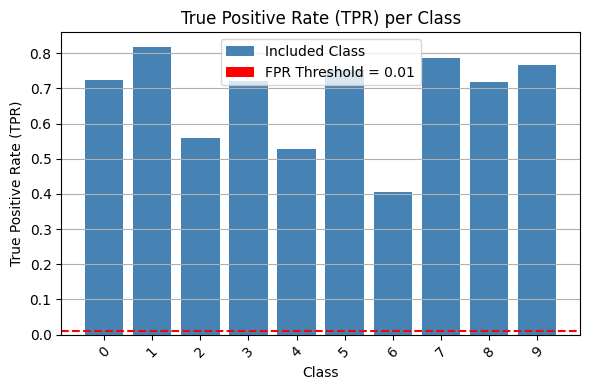

Average TPR across all classes:  0.6777200043201447


In [3]:
import numpy as np
from matplotlib.patches import Patch

# Plot the TPR for each class
import matplotlib.pyplot as plt

# Determine the colors for each class based on whether they are excluded
colors = ['steelblue' for cls in range(len(class_tprs))]

plt.figure(figsize=(6, 4))
plt.bar(range(len(class_tprs)), class_tprs, color=colors, tick_label=list(range(len(class_tprs))))
plt.xticks(rotation=45)
plt.axhline(y=fpr, color='r', linestyle='--', label='FPR Threshold = 0.01')
plt.xlabel('Class')
plt.ylabel('True Positive Rate (TPR)')
plt.title('True Positive Rate (TPR) per Class')

# Create custom legends for excluded and included classes
legend_elements = [Patch(facecolor='steelblue', label='Included Class'),
                   Patch(facecolor='r', linestyle='--', label='FPR Threshold = 0.01')]
plt.legend(handles=legend_elements)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("Average TPR across all classes: ", np.mean(class_tprs))

Excluding 1 class.

In [4]:
import torch
import pandas as pd

num_exclude = 2
folder = f"cifar10_excludeclass{num_exclude}"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')
print("Keys: " + str(eval_qr_results.keys()))

# Find the closest quantile to the FPR threshold on nonmembers.
fpr = 0.01
fpr, tpr, class_tprs, class_fprs = get_tprs(eval_qr_results, train_qr_results, fpr)
print(f"FPR: {fpr:.4f}")
print(f"TPR: {tpr:.4f}")
print("Class TPRs: " + str([f"{tpr:.4f}" for tpr in class_tprs]))
print("Class FPRs: " + str([f"{fpr:.4f}" for fpr in class_fprs]))

Keys: dict_keys(['images', 'labels', 'outputs', 'targets'])
FPR: 0.0096
TPR: 0.6684
Class TPRs: ['0.6976', '0.8416', '0.5248', '0.6952', '0.4856', '0.7384', '0.3816', '0.7968', '0.7148', '0.8080']
Class FPRs: ['0.0104', '0.0084', '0.0388', '0.0052', '0.0080', '0.0072', '0.0044', '0.0056', '0.0060', '0.0024']


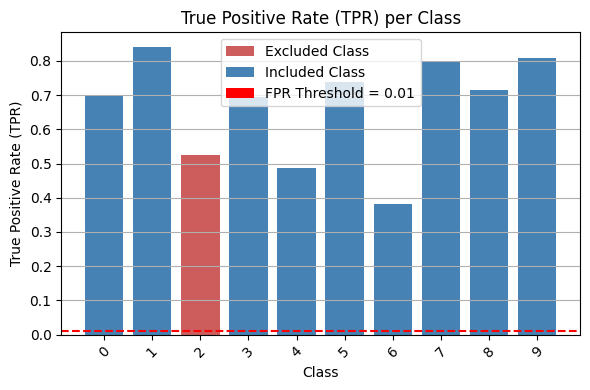

Average TPR across all classes:  0.6684400051832199


In [5]:
import numpy as np
from matplotlib.patches import Patch

# Identify the missing classes
# all_excluded_classes = np.load(f't_errors/cifar10/excluded_classes.npz', allow_pickle=True)
# excluded_classes = all_excluded_classes['excluded_classes'][num_exclude][0]
excluded_classes = [num_exclude]

# Plot the TPR for each class
import matplotlib.pyplot as plt

# Determine the colors for each class based on whether they are excluded
colors = ['indianred' if cls in excluded_classes else 'steelblue' for cls in range(len(class_tprs))]

plt.figure(figsize=(6, 4))
plt.bar(range(len(class_tprs)), class_tprs, color=colors, tick_label=list(range(len(class_tprs))))
plt.xticks(rotation=45)
plt.axhline(y=fpr, color='r', linestyle='--', label='FPR Threshold = 0.01')
plt.xlabel('Class')
plt.ylabel('True Positive Rate (TPR)')
plt.title('True Positive Rate (TPR) per Class')

# Create custom legends for excluded and included classes
legend_elements = [Patch(facecolor='indianred', label='Excluded Class'),
                   Patch(facecolor='steelblue', label='Included Class'),
                   Patch(facecolor='r', linestyle='--', label='FPR Threshold = 0.01')]
plt.legend(handles=legend_elements)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# print("Average TPR for included classes: ", np.mean([tpr for i, tpr in enumerate(class_tprs) if i not in excluded_classes]))
# print("Average TPR for excluded classes: ", np.mean([tpr for i, tpr in enumerate(class_tprs) if i in excluded_classes]))
print("Average TPR across all classes: ", np.mean(class_tprs))

Summary plot 1.

In [6]:
folder = f"cifar10_e200"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')

FPR = 0.01
base_fpr, base_tpr, base_tprs, base_fprs = get_tprs(eval_qr_results, train_qr_results, FPR)

excluded_tprs = []
excluded_fprs = []
for cls in np.arange(0, 10):
    folder = f"cifar10_excludeclass{cls}_e200"
    eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
    train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')
    fpr, tpr, class_tprs, class_fprs = get_tprs(eval_qr_results, train_qr_results, FPR)
    excluded_tprs.append(class_tprs[cls])
    excluded_fprs.append(class_fprs[cls])

print(f"Base TPRs: {[f'{tpr:.4f}' for tpr in base_tprs]}")
print(f"Base FPRs: {[f'{fpr:.4f}' for fpr in base_fprs]}")

print()
print(f"Excluded TPRs: {[f'{tpr:.4f}' for tpr in excluded_tprs]}")
print(f"Excluded FPRs: {[f'{fpr:.4f}' for fpr in excluded_fprs]}")

Base TPRs: ['0.8288', '0.9380', '0.6516', '0.7984', '0.5536', '0.8240', '0.5172', '0.8684', '0.8168', '0.9404']
Base FPRs: ['0.0184', '0.0156', '0.0096', '0.0088', '0.0088', '0.0084', '0.0088', '0.0064', '0.0096', '0.0048']

Excluded TPRs: ['0.8212', '0.9324', '0.6492', '0.8724', '0.7188', '0.8792', '0.0232', '0.8748', '0.9528', '0.9616']
Excluded FPRs: ['0.0968', '0.1152', '0.0664', '0.0808', '0.1200', '0.0940', '0.0032', '0.0692', '0.1656', '0.0452']


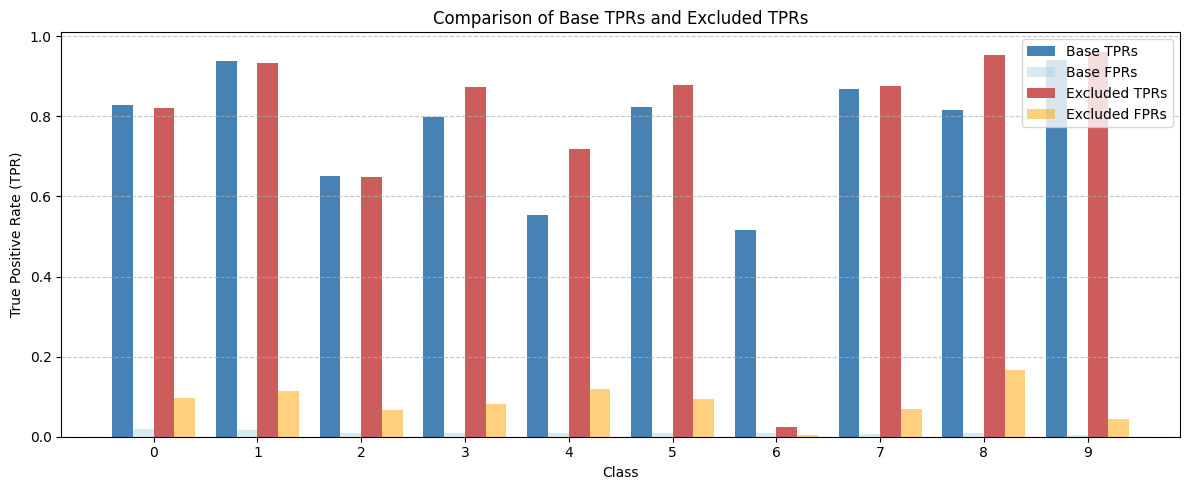

In [7]:
def plot_comparison(base_tprs, base_fprs, excluded_tprs, excluded_fprs):
    ind = np.arange(10)  # positions for classes 0 to 9
    width = 0.2         # width of the bars

    plt.figure(figsize=(12, 5))
    plt.bar(ind - 1.5*width, base_tprs, width, label='Base TPRs', color='steelblue')
    plt.bar(ind - 0.5*width, base_fprs, width, label='Base FPRs', color='lightblue', alpha=0.5)
    plt.bar(ind + 0.5*width, excluded_tprs, width, label='Excluded TPRs', color='indianred')
    plt.bar(ind + 1.5*width, excluded_fprs, width, label='Excluded FPRs', color='orange', alpha=0.5)
    plt.xlabel('Class')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Comparison of Base TPRs and Excluded TPRs')
    plt.xticks(ind)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_comparison(base_tprs, base_fprs, excluded_tprs, excluded_fprs)

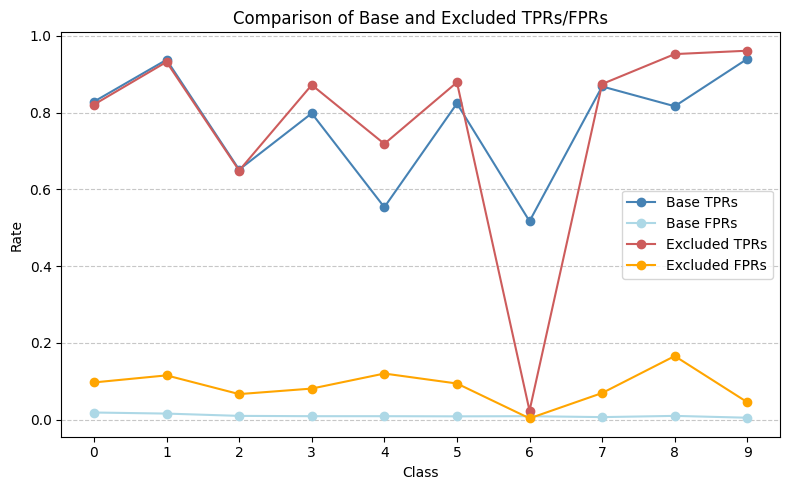

In [8]:
def line_plot_comparison(base_tprs, base_fprs, excluded_tprs, excluded_fprs):
    ind = np.arange(10)  # positions for classes 0 to 9

    plt.figure(figsize=(8, 5))
    plt.plot(ind, base_tprs, marker='o', color='steelblue', label='Base TPRs')
    plt.plot(ind, base_fprs, marker='o', color='lightblue', label='Base FPRs')
    plt.plot(ind, excluded_tprs, marker='o', color='indianred', label='Excluded TPRs')
    plt.plot(ind, excluded_fprs, marker='o', color='orange', label='Excluded FPRs')

    plt.xlabel('Class')
    plt.ylabel('Rate')
    plt.title('Comparison of Base and Excluded TPRs/FPRs')
    plt.xticks(ind)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

line_plot_comparison(base_tprs, base_fprs, excluded_tprs, excluded_fprs)

Summary Plot 2.

In [3]:
# Find the closest quantile to the FPR threshold on nonmembers SPECIFICALLY from a certain class.
def get_class_tpr(eval_qr_results, train_qr_results, class_i, fpr):
    eval_preds = eval_qr_results['outputs'] < eval_qr_results['targets']

    class_preds = eval_preds[eval_qr_results['labels'] == class_i]
    class_fprs = torch.sum(class_preds, dim=0) / class_preds.shape[0]
    best_q_idx = torch.argmin(torch.abs(class_fprs - fpr))
    
    # Evaluate the per-class TPR on members using the best quantile found above.
    train_preds = train_qr_results['outputs'] < train_qr_results['targets']

    class_preds = train_preds[train_qr_results['labels'] == class_i]
    class_tpr = torch.sum(class_preds, dim=0) / class_preds.shape[0]
    class_tpr = class_tpr[best_q_idx].item()

    return class_fprs[best_q_idx].item(), class_tpr

In [16]:
import numpy as np

folder = f"cifar10"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')

FPR = 0.01

base_fpr, base_tpr, base_tprs, base_fprs = get_tprs(eval_qr_results, train_qr_results, FPR)

class_excluded_tprs = []
class_excluded_fprs = []
avg_class_excluded_tprs = []
avg_class_excluded_fprs = []

for clas in np.arange(0, 10):
    folder = f"cifar10_excludeclass{clas}"
    eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
    train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')
    cls_fpr, cls_tpr = get_class_tpr(eval_qr_results, train_qr_results, clas, FPR)
    class_excluded_tprs.append(cls_tpr)
    class_excluded_fprs.append(cls_fpr)

    fpr, tpr, _, _ = get_tprs(eval_qr_results, train_qr_results, FPR)
    avg_class_excluded_fprs.append(fpr)
    avg_class_excluded_tprs.append(tpr)

print(f"Base TPRs: {[f'{tpr:.4f}' for tpr in base_tprs]}")
print(f"Base FPRs: {[f'{fpr:.4f}' for fpr in base_fprs]}")
print()
print(f"Excluded TPRs: {[f'{tpr:.4f}' for tpr in class_excluded_tprs]}")
print(f"Excluded FPRs: {[f'{fpr:.4f}' for fpr in class_excluded_fprs]}")
print()
print(f"Avg Excluded TPRs: {[f'{tpr:.4f}' for tpr in avg_class_excluded_tprs]}")
print(f"Avg Excluded FPRs: {[f'{fpr:.4f}' for fpr in avg_class_excluded_fprs]}")

Base TPRs: ['0.7008', '0.9176', '0.5068', '0.7224', '0.4792', '0.7576', '0.4640', '0.8452', '0.7140', '0.9288']
Base FPRs: ['0.0088', '0.0204', '0.0072', '0.0076', '0.0092', '0.0100', '0.0156', '0.0104', '0.0052', '0.0120']

Excluded TPRs: ['0.3916', '0.0876', '0.2392', '0.4268', '0.2184', '0.7096', '0.1916', '0.5080', '0.6308', '0.7504']
Excluded FPRs: ['0.0100', '0.0112', '0.0088', '0.0076', '0.0084', '0.0104', '0.0092', '0.0104', '0.0108', '0.0108']

Avg Excluded TPRs: ['0.5889', '0.5790', '0.6684', '0.6347', '0.5915', '0.6581', '0.6035', '0.6672', '0.7228', '0.6458']
Avg Excluded FPRs: ['0.0093', '0.0094', '0.0096', '0.0100', '0.0094', '0.0096', '0.0091', '0.0096', '0.0097', '0.0100']


In [17]:
# plot_comparison(base_tprs, base_fprs, class_excluded_tprs, class_excluded_fprs)
# line_plot_comparison(base_tprs, base_fprs, class_excluded_tprs, class_excluded_fprs)

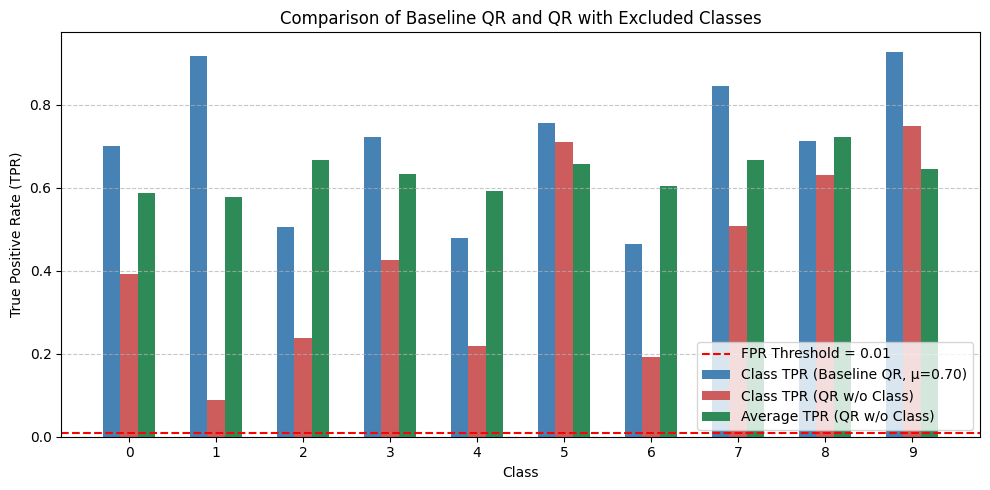

In [18]:
import matplotlib.pyplot as plt

ind = np.arange(10)  # positions for classes 0 to 9
width = 0.2         # width of the bars

plt.figure(figsize=(10, 5))
plt.bar(ind - 1*width, base_tprs, width, label=f'Class TPR (Baseline QR, μ={base_tpr:.2f})', color='steelblue')
plt.bar(ind, class_excluded_tprs, width, label='Class TPR (QR w/o Class)', color='indianred')
plt.bar(ind + width, avg_class_excluded_tprs, width, label='Average TPR (QR w/o Class)', color='seagreen')
plt.xlabel('Class')
plt.ylabel('True Positive Rate (TPR)')
plt.axhline(y=fpr, color='r', linestyle='--', label=f'FPR Threshold = {FPR:g}')
plt.title('Comparison of Baseline QR and QR with Excluded Classes')
plt.xticks(ind)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

CelebA plot.

In [ ]:
import torch
import pandas as pd

folder = f"cifar10_e200"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')
fpr = 0.01
base_fpr, base_tpr, base_tprs, base_fprs = get_tprs(eval_qr_results, train_qr_results, fpr)

print(f"Base TPRs: {[f'{tpr:.4f}' for tpr in base_tprs]}")
print(f"Base FPRs: {[f'{fpr:.4f}' for fpr in base_fprs]}")

# Find the closest quantile to the FPR threshold on nonmembers for EACH CLASS SEPARATELY.
celebaqr_fprs = []
celebaqr_tprs = []

folder = f"cifar10_on_celeba_e200"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')

for cls in np.arange(0, 10):
    cls_fpr, cls_tpr = get_class_tpr(eval_qr_results, train_qr_results, cls, fpr)
    celebaqr_tprs.append(cls_tpr)
    celebaqr_fprs.append(cls_fpr)

print("CelebA-QR TPRs: " + str([f"{tpr:.4f}" for tpr in celebaqr_tprs]))
print("CelebA-QR FPRs: " + str([f"{fpr:.4f}" for fpr in celebaqr_fprs]))

Base TPRs: ['0.8288', '0.9380', '0.6516', '0.7984', '0.5536', '0.8240', '0.5172', '0.8684', '0.8168', '0.9404']
Base FPRs: ['0.0184', '0.0156', '0.0096', '0.0088', '0.0088', '0.0084', '0.0088', '0.0064', '0.0096', '0.0048']
CelebA-QR TPRs: ['0.8164', '0.8920', '0.5252', '0.6768', '0.4308', '0.7200', '0.3952', '0.8028', '0.7744', '0.8388']
CelebA-QR FPRs: ['0.1384', '0.0904', '0.0532', '0.0216', '0.0276', '0.0228', '0.0352', '0.0404', '0.0508', '0.0172']


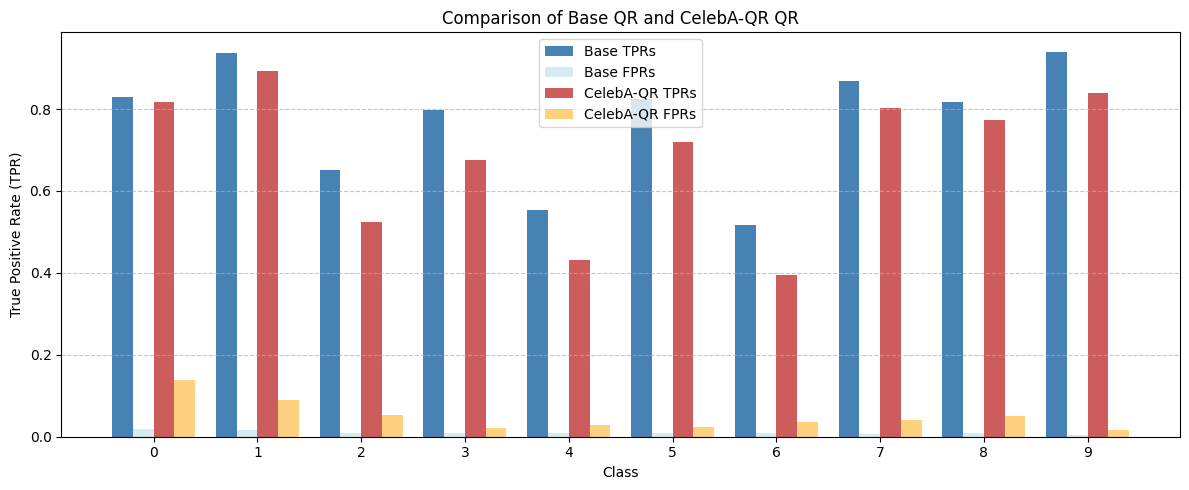

In [ ]:
ind = np.arange(10)  # positions for classes 0 to 9
width = 0.2         # width of the bars

plt.figure(figsize=(12, 5))
plt.bar(ind - 1.5*width, base_tprs, width, label='Base TPRs', color='steelblue')
plt.bar(ind - 0.5*width, base_fprs, width, label='Base FPRs', color='lightblue', alpha=0.5)
plt.bar(ind + 0.5*width, celebaqr_tprs, width, label='CelebA-QR TPRs', color='indianred')
plt.bar(ind + 1.5*width, celebaqr_fprs, width, label='CelebA-QR FPRs', color='orange', alpha=0.5)
plt.xlabel('Class')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Comparison of Base QR and CelebA-QR QR')
plt.xticks(ind)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

CIFAR100 plot.

In [ ]:
import torch
import pandas as pd
import numpy as np

folder = f"cifar10_e200"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')
fpr = 0.01
base_fpr, base_tpr, base_tprs, base_fprs = get_tprs(eval_qr_results, train_qr_results, fpr)

print(f"Base TPRs: {[f'{tpr:.4f}' for tpr in base_tprs]}")
print(f"Base FPRs: {[f'{fpr:.4f}' for fpr in base_fprs]}")

# Find the closest quantile to the FPR threshold on nonmembers for EACH CLASS SEPARATELY.
celebaqr_fprs = []
celebaqr_tprs = []

folder = f"cifar10_on_cifar100_e200"
eval_qr_results = torch.load(f'qr_results/{folder}/qr_results_eval.pt', map_location='cpu')
train_qr_results = torch.load(f'qr_results/{folder}/qr_results_train.pt', map_location='cpu')

for cls in np.arange(0, 10):
    cls_fpr, cls_tpr = get_class_tpr(eval_qr_results, train_qr_results, cls, fpr)
    celebaqr_tprs.append(cls_tpr)
    celebaqr_fprs.append(cls_fpr)

print("CIFAR-100 TPRs: " + str([f"{tpr:.4f}" for tpr in celebaqr_tprs]))
print("CIFAR-100 FPRs: " + str([f"{fpr:.4f}" for fpr in celebaqr_fprs]))

Base TPRs: ['0.8288', '0.9380', '0.6516', '0.7984', '0.5536', '0.8240', '0.5172', '0.8684', '0.8168', '0.9404']
Base FPRs: ['0.0184', '0.0156', '0.0096', '0.0088', '0.0088', '0.0084', '0.0088', '0.0064', '0.0096', '0.0048']
CIFAR-100 TPRs: ['0.6672', '0.7308', '0.5184', '0.8020', '0.4340', '0.8128', '0.4144', '0.8160', '0.7892', '0.9556']
CIFAR-100 FPRs: ['0.0100', '0.0264', '0.0096', '0.0108', '0.0096', '0.0100', '0.0088', '0.0108', '0.0092', '0.0104']


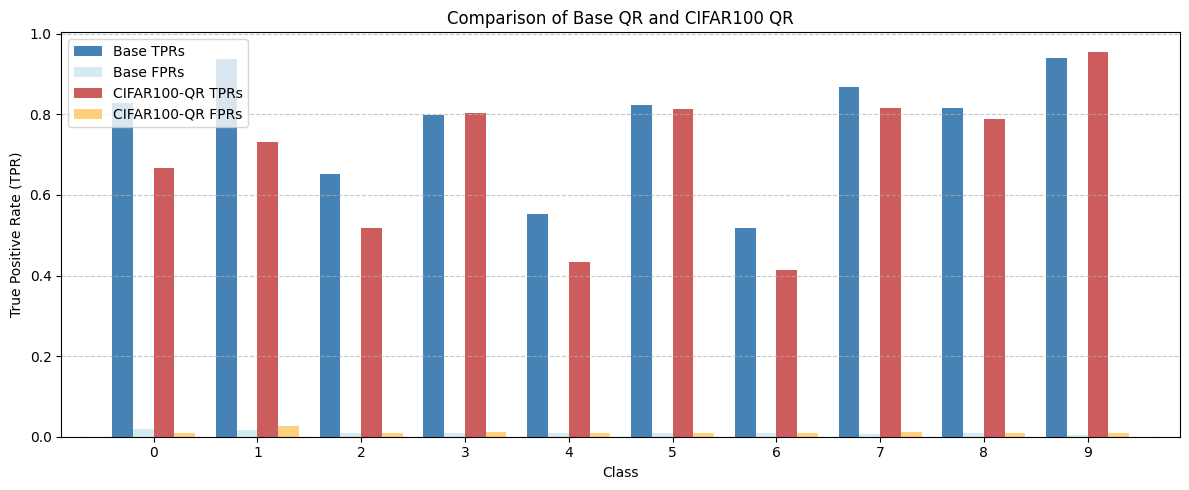

In [ ]:
import matplotlib.pyplot as plt

ind = np.arange(10)  # positions for classes 0 to 9
width = 0.2         # width of the bars

plt.figure(figsize=(12, 5))
plt.bar(ind - 1.5*width, base_tprs, width, label='Base TPRs', color='steelblue')
plt.bar(ind - 0.5*width, base_fprs, width, label='Base FPRs', color='lightblue', alpha=0.5)
plt.bar(ind + 0.5*width, celebaqr_tprs, width, label='CIFAR100-QR TPRs', color='indianred')
plt.bar(ind + 1.5*width, celebaqr_fprs, width, label='CIFAR100-QR FPRs', color='orange', alpha=0.5)
plt.xlabel('Class')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Comparison of Base QR and CIFAR100 QR')
plt.xticks(ind)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()